## What are the most demanded Skills for the Top 3 most popular Data roles?

#### Methodology:
1. clean-up skill column
2. Calculate skill count based on 'job_title_short'
3. Calculate skill percentage
4. Plot final findings

In [3]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_US = df[df['job_country'] == 'United States']
df_skills = df_US.explode('job_skills')

df_skill_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skill_count = df_skill_count.reset_index(name='skill_count')
df_skill_count.sort_values(by='skill_count', ascending=False, inplace=True)


In [35]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='job_total')

df_skill_percent = pd.merge(df_skill_count, df_job_title_count, how='left', on='job_title_short')

df_skill_percent['skill_percent'] = round(df_skill_percent['skill_count'] / df_skill_percent['job_total']*100, 2)

df_skill_percent

,job_skills,job_title_short,skill_count,job_total,skill_percent
0,python,Data Scientist,42379,58830,72.04
1,sql,Data Analyst,34452,67816,50.80
2,sql,Data Scientist,30034,58830,51.05
3,excel,Data Analyst,27519,67816,40.58
4,r,Data Scientist,26022,58830,44.23
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.01
1866,arch,Business Analyst,1,7382,0.01
1867,asana,Machine Learning Engineer,1,921,0.11
1868,no-sql,Machine Learning Engineer,1,921,0.11


In [17]:
job_titles = df_skill_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

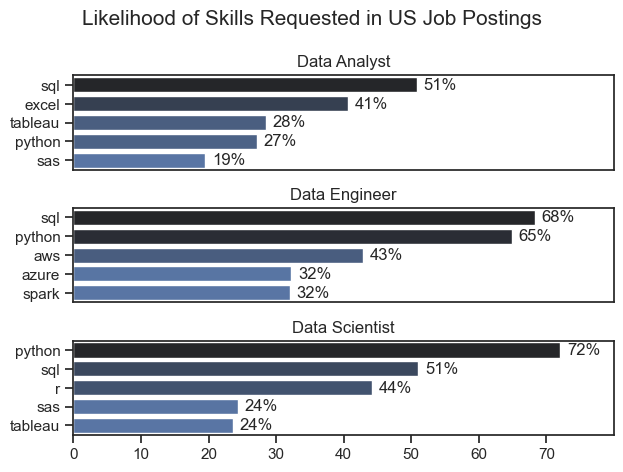

In [80]:
# Calculate skill percentage
fig, ax = plt.subplots(len(job_titles), 1)
sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_percent[df_skill_percent['job_title_short'] == job_title].head()
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0,80)
    ax[i].set_xticks(range(0, 80, 10))
    ax[i].legend().set_visible(False)

    for j, value in enumerate(df_plot['skill_percent']):
        ax[i].text(value+1, j, f'{value:.0f}%', va='center')

    if i != len(job_titles)-1:
        ax[i].set_xticks([])

fig.suptitle("Likelihood of Skills Requested in US Job Postings", fontsize=15)
fig.tight_layout()
plt.show()


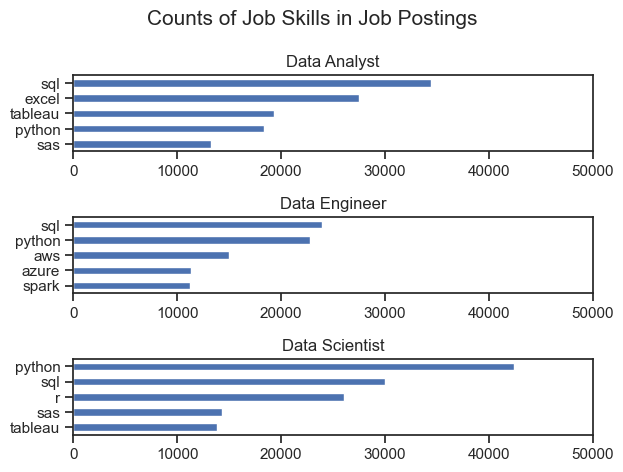

In [65]:
# Calculate skill count
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_count[df_skill_count['job_title_short'] == job_title].head()
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlim(0, 50000)
    ax[i].legend().set_visible(False)

fig.suptitle("Counts of Job Skills in Job Postings", fontsize=15)
fig.tight_layout()
plt.show()
